In [2]:
import xarray as xr
import matplotlib.pyplot as plt

matched 2025-07-27 | valid 100.0%


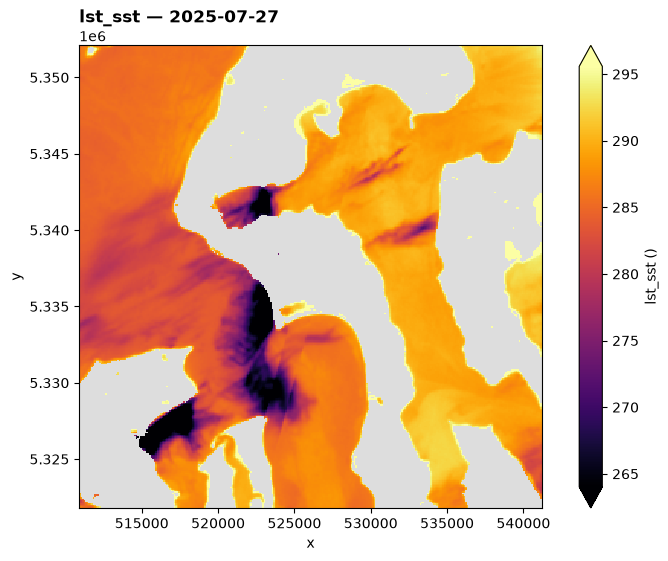

In [46]:
ds = xr.open_zarr("../data/unfiltered/admiralty_inlet.zarr")
VAR  = "lst_sst"
date = "2025-07-27"


da = ds[VAR].sel(time=date, method="nearest").compute()
mask = ds["landcover_water"].compute()
da_masked = da.where(mask>0.5)
print(f"matched {str(da.time.values)[:10]} | valid {float(da.notnull().mean()):.1%}")

cmap = plt.get_cmap("inferno").copy()
cmap.set_bad("#DDDDDD")                      # masked/cloud pixels visible

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
da_masked.plot.imshow(ax=ax, cmap=cmap, robust=True, interpolation="nearest",
               cbar_kwargs={"label": f"{VAR} ({da_masked.attrs.get('units', '')})"})
ax.set_aspect("equal")
ax.set_title("")                             # clear xarray's auto "time = ..." title
ax.set_title(f"{VAR} — {str(da_masked.time.values)[:10]}", loc="left", fontweight="bold")
plt.show()

/Users/johnbuckner/miniconda3/envs/coastal_sst_data/lib/python3.11/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


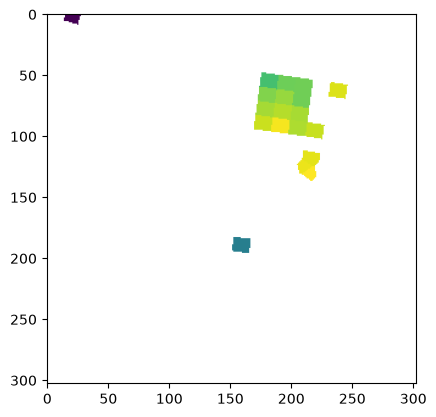

In [51]:
import os, sys
module_path = os.path.abspath(os.path.join('../src'))
if module_path not in sys.path:
    sys.path.append(module_path)

from outlier_detection import (
    DEFAULTS,
    LAND_COLOR,
    ROOT,
    _plain,
    acquisition_dates,
    estep,
    load_config,
    load_inputs,
    robust_centre_scale,
    robust_modis_composite,
    solve_spde,
    unary_logodds,
    build_covariate
)
date = "2025-07-27"
comp, n = robust_modis_composite(ds, date, "modis_sst_aqua", "landcover_water", window_days=2)
plt.imshow(comp)

/Users/johnbuckner/miniconda3/envs/coastal_sst_data/lib/python3.11/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


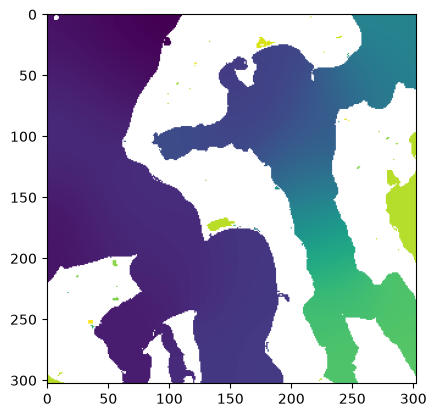

In [29]:
cfg = DEFAULTS
covariate, modis_raw, n_ref = build_covariate(ds, date, ds["landcover_water"] > 0.5, cfg)
plt.imshow(covariate)

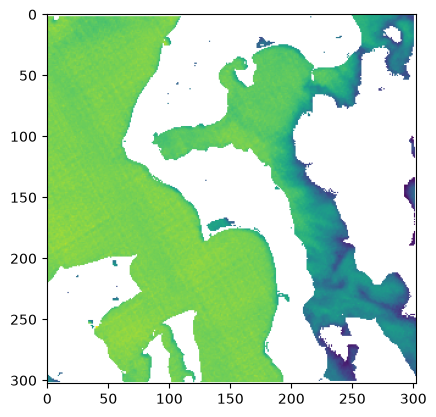

In [30]:
import numpy as np
resids = np.asarray(da) - covariate
plt.imshow(resids)

(array([1.4300e+02, 4.6900e+02, 1.1090e+03, 1.8760e+03, 3.4050e+03,
        3.1070e+03, 2.6890e+03, 2.2556e+04, 1.4561e+04, 3.0000e+00]),
 array([-9.34190407, -7.8951563 , -6.44840853, -5.00166075, -3.55491298,
        -2.1081652 , -0.66141743,  0.78533035,  2.23207812,  3.67882589,
         5.12557367]),
 <BarContainer object of 10 artists>)

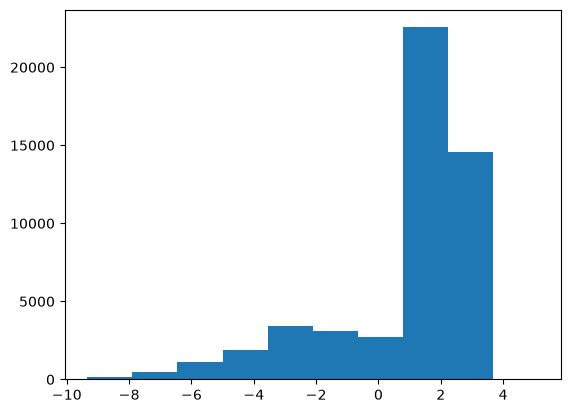

In [31]:
plt.hist(resids.ravel())

In [ ]:
outlier = xr.open_dataset("../outputs/simple_outlier_detection/eco_sst_v002_2025-03-05.nc", engine="netcdf4")

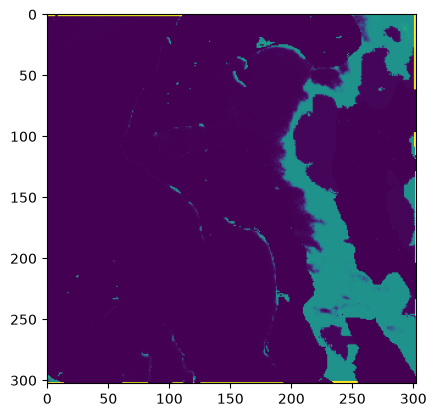

In [38]:
plt.imshow(outlier["q_cloud"])

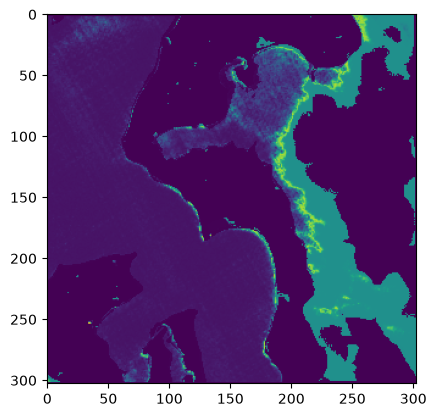

In [39]:
plt.imshow(outlier["q_hot"])